In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings
import pickle
import numpy as np
warnings.filterwarnings('ignore')
%matplotlib inline
from sklearn.model_selection import train_test_split

In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [5]:
# Load normal images
X = np.load("/content/drive/MyDrive/processed/X_images.npy")

# Params used globally
IMG_SIZE = 256
BATCH_SIZE = 16
NOISE_FACTOR = 0.5
VAL_SPLIT = 0.1

# Size of normal images
print("Normal Images:", X.shape)

Normal Images: (2906, 256, 256, 3)


In [6]:
# Array for index (0 -> size of our images (approx 3000))
indices = np.arange(len(X))

# Split index in tran/test
train_idx, test_idx = train_test_split(indices, test_size=0.1, random_state=42)

# Determine the size of the validation set
val_size = int(len(train_idx) * VAL_SPLIT)

# Shuffle index of the train so we have variation in train/val
np.random.seed(42)
np.random.shuffle(train_idx)

# Validation set
val_idx = train_idx[:val_size]

# Training set
train_idx = train_idx[val_size:]

In [7]:
def batch_generator(X_array, indices, batch_size=BATCH_SIZE, noise_factor=NOISE_FACTOR, clip=False):
    """
    Generator of noisy and clean  pair images for AE

    Args:
        X_array: Images you wish to create pairs for
        indices: index of the images to select
        batch_size: number of images per batch
        noise_factor: scale of the noise to add
        clip: clip scale of images [0,1]

    returns:
        X_noisy: batch of noisy images[input]
        X_batch: batch of clean images [target]
    """

    while True:
        # Shuffle indexes to randomize batches
        np.random.shuffle(indices)

        # Iterate over the index
        for start in range(0, len(indices), batch_size):
            batch_idx = indices[start:start+batch_size]  # Indexes of this batch round
            X_batch = X_array[batch_idx].astype(np.float32)  # Select those images from the dataset

            # Add Gaussian noise
            X_noisy = X_batch + noise_factor * np.random.normal(0.0, 1.0, X_batch.shape)

            # Clip values between [0,1]
            if clip:
                X_noisy = np.clip(X_noisy, 0.0, 1.0)

            yield X_noisy, X_batch

# Create training and validation generators
train_gen = batch_generator(X, train_idx)
val_gen   = batch_generator(X, val_idx)

# How many batches per epoch [training]
STEPS_PER_EPOCH = len(train_idx) // BATCH_SIZE

# Same but for val set
VAL_STEPS = len(val_idx) // BATCH_SIZE

In [19]:
def test_generator(X_array, batch_size=BATCH_SIZE, noise_factor=NOISE_FACTOR, clip=False):
  """
    Generator of noisy and clean  pair images for AE prediction

    Args:
        X_array: Images you wish to create pairs for
        batch_size: number of images per batch
        noise_factor: scale of the noise to add
        clip: clip scale of images [0,1]

    returns:
        X_noisy: batch of noisy images[input]
        X_batch: batch of clean images [target]
    """

  # Iterate for the whole test set
  for start in range(0, len(X_array), batch_size):
    batch_idx = np.arange(start, min(start+batch_size, len(X_array))) # Indexes of this batch round
    X_batch = X_array[batch_idx].astype(np.float32) # Select those images

    # Add Gaussian noise
    X_noisy = X_batch + noise_factor * np.random.normal(0.0, 1.0, X_batch.shape)

    # Clip values between [0,1]
    if clip:
        X_noisy = np.clip(X_noisy, 0.0, 1.0)

    yield X_noisy, X_batch


In [8]:
import tensorflow as tf
from tensorflow.keras import layers, models

In [11]:
# Encoder
input_img = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

x = layers.Conv2D(32, 3, padding='same', activation='relu')(input_img)
x = layers.MaxPooling2D(2, padding='same')(x)
x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
encoded_simple = layers.MaxPooling2D(2, padding='same')(x)

# Decoder
x = layers.Conv2D(64, 3, padding='same', activation='relu')(encoded_simple)
x = layers.UpSampling2D(2)(x)
x = layers.Conv2D(32, 3, padding='same', activation='relu')(x)
x = layers.UpSampling2D(2)(x)
decoded_simple = layers.Conv2D(3, 3, padding='same', activation='sigmoid')(x)

autoencoder_simple_mse = models.Model(input_img, decoded_simple)
autoencoder_simple_mse.compile(optimizer='adam', loss='mse')
autoencoder_simple_mse.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_4 (UpSampling2D)  │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 128, 128, 32)   │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_5 (UpSampling2D)  │ (None, 256, 256, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 256, 256, 3)    │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,651 (295.51 KB)

 Trainable params: 75,651 (295.51 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
EPOCHS = 10

history_simple_mse = autoencoder_simple_mse.fit(train_gen, steps_per_epoch=STEPS_PER_EPOCH, validation_data=val_gen, validation_steps=VAL_STEPS, epochs=EPOCHS)

Epoch 1/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 33s 153ms/step - loss: 0.0339 - val_loss: 0.0045
Epoch 2/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 40s 237ms/step - loss: 0.0040 - val_loss: 0.0036
Epoch 3/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 25s 173ms/step - loss: 0.0033 - val_loss: 0.0034
Epoch 4/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 21s 146ms/step - loss: 0.0031 - val_loss: 0.0034
Epoch 5/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 40s 274ms/step - loss: 0.0030 - val_loss: 0.0029
Epoch 6/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 22s 147ms/step - loss: 0.0028 - val_loss: 0.0029
Epoch 7/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 21s 141ms/step - loss: 0.0027 - val_loss: 0.0028
Epoch 8/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 22s 148ms/step - loss: 0.0027 - val_loss: 0.0028
Epoch 9/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 23s 156ms/step - loss: 0.0027 - val_loss: 0.0025
Epoch 10/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 25s 167ms/step - loss: 0.0025 - val_loss: 0.0025


In [24]:
# Save the full DAE
autoencoder_simple_mse.save("/content/drive/MyDrive/processed/Models/dae_simple_mse.keras")

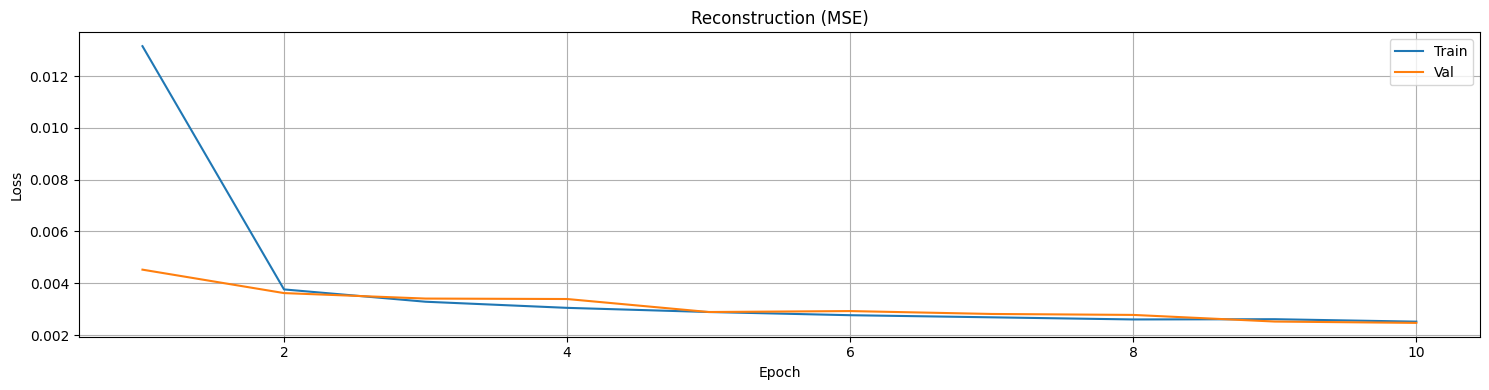

In [17]:
fig, ax = plt.subplots(1, 1, figsize=(15, 4))

# Plot train and validation loss
ax.plot(epochs, history_simple_mse.history["loss"], label="Train")
ax.plot(epochs, history_simple_mse.history["val_loss"], label="Val")
ax.set_title("Reconstruction (MSE)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

In [21]:
# Predict and store denoised images
denoised_images = []

for X_noisy_batch, X_clean_batch in test_generator(X[test_idx], batch_size=BATCH_SIZE, noise_factor=NOISE_FACTOR):
    denoised_batch = autoencoder_simple_mse.predict(X_noisy_batch)
    denoised_images.append(denoised_batch)

denoised_images = np.concatenate(denoised_images, axis=0)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


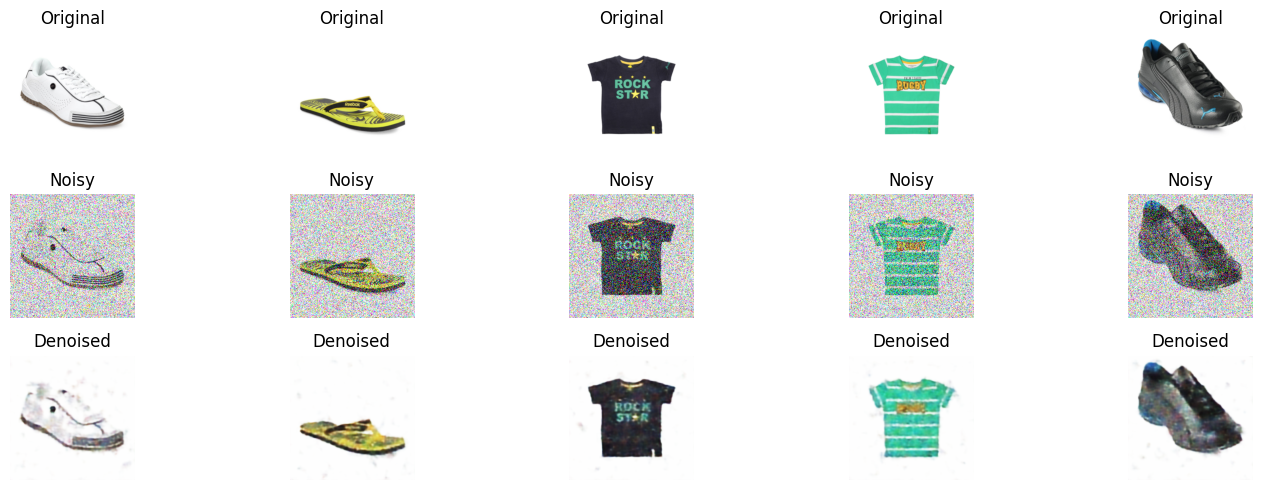

In [22]:
def plot_denoising_results(X, denoised_images, test_idx, n=5, noise_factor=0.5, random_seed=42):
    """
    Plot noisy, denoised, and original images

    Args:
        X: Original images
        denoised_images: DAE predictions
        test_idx: indexes to sample from test
        n: number of images to plot
        noise_factor: scale of Gnoise to add
        random_seed: seed for numpy
    """
    if random_seed is not None:
        np.random.seed(random_seed)

    indices_plot = np.random.choice(len(test_idx), n, replace=False)

    plt.figure(figsize=(15, 5))

    for i, idx in enumerate(indices_plot):
        # Original
        ax = plt.subplot(3, n, i + 1)
        plt.imshow(X[test_idx[idx]])
        plt.title("Original")
        plt.axis('off')

        # Noise
        ax = plt.subplot(3, n, i + 1 + n)
        noisy_img = np.clip(X[test_idx[idx]] + noise_factor * np.random.normal(0.0, 1.0, X[test_idx[idx]].shape), 0.0, 1.0)
        plt.imshow(noisy_img)
        plt.title("Noisy")
        plt.axis('off')

        # Prediction
        ax = plt.subplot(3, n, i + 1 + 2 * n)
        plt.imshow(denoised_images[idx])
        plt.title("Denoised")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

plot_denoising_results(X, denoised_images, test_idx, n=5, noise_factor=NOISE_FACTOR, random_seed=42)

In [25]:
autoencoder_simple_mae = models.Model(input_img, decoded_simple)
autoencoder_simple_mae.compile(optimizer='adam', loss='mae')
autoencoder_simple_mae.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_4 (UpSampling2D)  │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 128, 128, 32)   │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_5 (UpSampling2D)  │ (None, 256, 256, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 256, 256, 3)    │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,651 (295.51 KB)

 Trainable params: 75,651 (295.51 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
EPOCHS = 10

history_simple_mae = autoencoder_simple_mae.fit(train_gen, steps_per_epoch=STEPS_PER_EPOCH, validation_data=val_gen, validation_steps=VAL_STEPS, epochs=EPOCHS)

Epoch 1/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 27s 165ms/step - loss: 0.0263 - val_loss: 0.0206
Epoch 2/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 22s 152ms/step - loss: 0.0198 - val_loss: 0.0190
Epoch 3/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 20s 140ms/step - loss: 0.0192 - val_loss: 0.0186
Epoch 4/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 22s 147ms/step - loss: 0.0188 - val_loss: 0.0192
Epoch 5/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 21s 143ms/step - loss: 0.0188 - val_loss: 0.0185
Epoch 6/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 41s 278ms/step - loss: 0.0180 - val_loss: 0.0183
Epoch 7/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 41s 282ms/step - loss: 0.0195 - val_loss: 0.0179
Epoch 8/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 21s 141ms/step - loss: 0.0180 - val_loss: 0.0185
Epoch 9/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 22s 150ms/step - loss: 0.0178 - val_loss: 0.0180
Epoch 10/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 21s 140ms/step - loss: 0.0179 - val_loss: 0.0185


In [31]:

history_simple_mae = autoencoder_simple_mae.fit(train_gen, steps_per_epoch=STEPS_PER_EPOCH, validation_data=val_gen, validation_steps=VAL_STEPS, epochs=4)

Epoch 1/4
147/147 ━━━━━━━━━━━━━━━━━━━━ 20s 139ms/step - loss: 0.0178 - val_loss: 0.0178
Epoch 2/4
147/147 ━━━━━━━━━━━━━━━━━━━━ 22s 148ms/step - loss: 0.0174 - val_loss: 0.0181
Epoch 3/4
147/147 ━━━━━━━━━━━━━━━━━━━━ 22s 147ms/step - loss: 0.0174 - val_loss: 0.0180
Epoch 4/4
147/147 ━━━━━━━━━━━━━━━━━━━━ 22s 147ms/step - loss: 0.0174 - val_loss: 0.0222


In [30]:
# Save the full DAE
autoencoder_simple_mae.save("/content/drive/MyDrive/processed/Models/dae_simple_mae.keras")

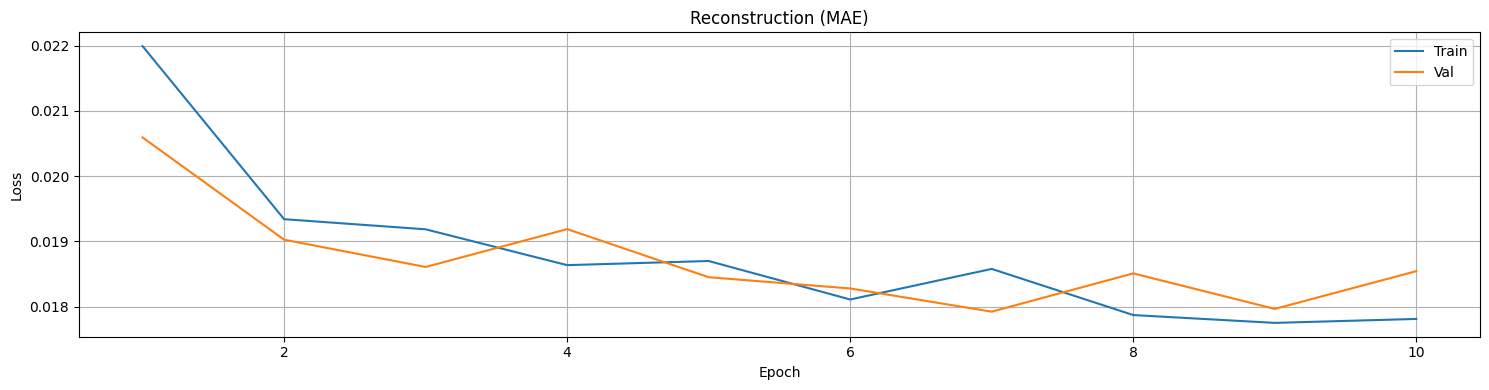

In [27]:
fig, ax = plt.subplots(1, 1, figsize=(15, 4))

# Plot train and validation loss
ax.plot(epochs, history_simple_mae.history["loss"], label="Train")
ax.plot(epochs, history_simple_mae.history["val_loss"], label="Val")
ax.set_title("Reconstruction (MAE)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

In [28]:
# Predict and store denoised images
denoised_images = []

for X_noisy_batch, X_clean_batch in test_generator(X[test_idx], batch_size=BATCH_SIZE, noise_factor=NOISE_FACTOR):
    denoised_batch = autoencoder_simple_mae.predict(X_noisy_batch)
    denoised_images.append(denoised_batch)

denoised_images = np.concatenate(denoised_images, axis=0)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 520ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 453ms/step


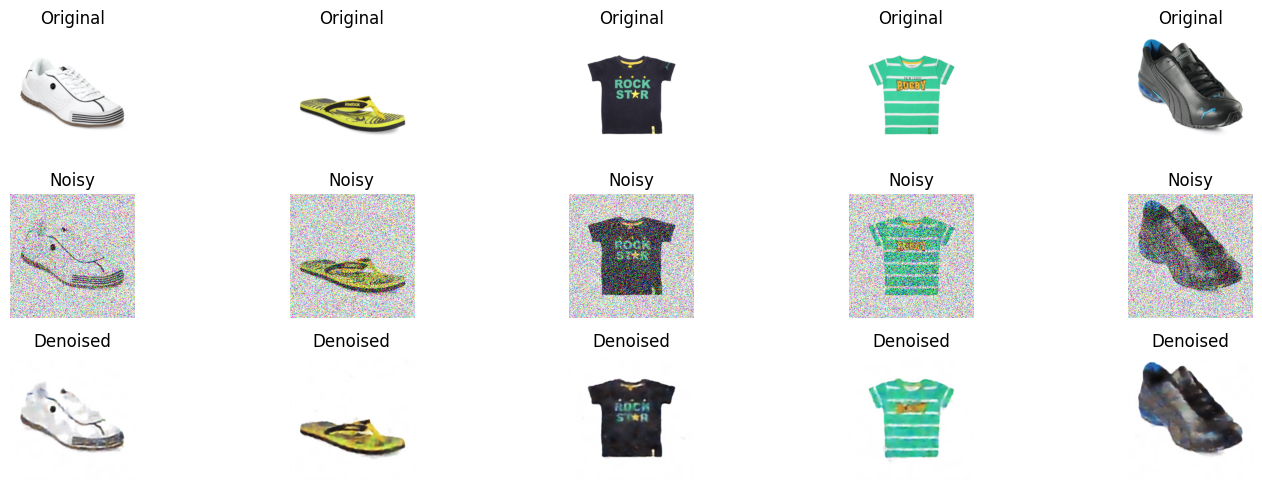

In [29]:
plot_denoising_results(X, denoised_images, test_idx, n=5, noise_factor=NOISE_FACTOR, random_seed=42)

In [8]:
input_img = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

# Encoder
x = layers.Conv2D(64, 3, padding='same', kernel_initializer='he_normal')(input_img)
x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)
x = layers.MaxPooling2D(2, padding='same')(x)

x = layers.Conv2D(128, 3, padding='same', kernel_initializer='he_normal')(x)
x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)
x = layers.MaxPooling2D(2, padding='same')(x)

x = layers.Conv2D(256, 3, padding='same', kernel_initializer='he_normal')(x)
x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)
encoded = layers.MaxPooling2D(2, padding='same')(x)

# Decoder
x = layers.Conv2D(256, 3, padding='same', kernel_initializer='he_normal')(encoded)
x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)
x = layers.UpSampling2D(2)(x)

x = layers.Conv2D(128, 3, padding='same', kernel_initializer='he_normal')(x)
x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)
x = layers.UpSampling2D(2)(x)

x = layers.Conv2D(64, 3, padding='same', kernel_initializer='he_normal')(x)
x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)
x = layers.UpSampling2D(2)(x)

decoded = layers.Conv2D(3, 3, activation='sigmoid', padding='same')(x)

autoencoder = models.Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 256, 256, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256, 256, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 256, 256, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 128, 128, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 64, 64, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 64, 64, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 128)    │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 128, 128, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 128, 128, 64)   │        73,792 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,335,043 (5.09 MB)

 Trainable params: 1,333,251 (5.09 MB)

 Non-trainable params: 1,792 (7.00 KB)

In [11]:
EPOCHS = 10

history = autoencoder.fit(train_gen, steps_per_epoch=STEPS_PER_EPOCH, validation_data=val_gen, validation_steps=VAL_STEPS, epochs=EPOCHS)

Epoch 1/5
294/294 ━━━━━━━━━━━━━━━━━━━━ 32s 108ms/step - loss: 0.0041 - val_loss: 0.0051
Epoch 2/5
294/294 ━━━━━━━━━━━━━━━━━━━━ 32s 109ms/step - loss: 0.0038 - val_loss: 0.0033
Epoch 3/5
294/294 ━━━━━━━━━━━━━━━━━━━━ 41s 139ms/step - loss: 0.0033 - val_loss: 0.0032
Epoch 4/5
294/294 ━━━━━━━━━━━━━━━━━━━━ 36s 121ms/step - loss: 0.0032 - val_loss: 0.0068
Epoch 5/5
294/294 ━━━━━━━━━━━━━━━━━━━━ 31s 106ms/step - loss: 0.0031 - val_loss: 0.0036


In [15]:
# Save the full DAE
autoencoder.save("/content/drive/MyDrive/processed/Models/dse_complex_mse.keras")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step


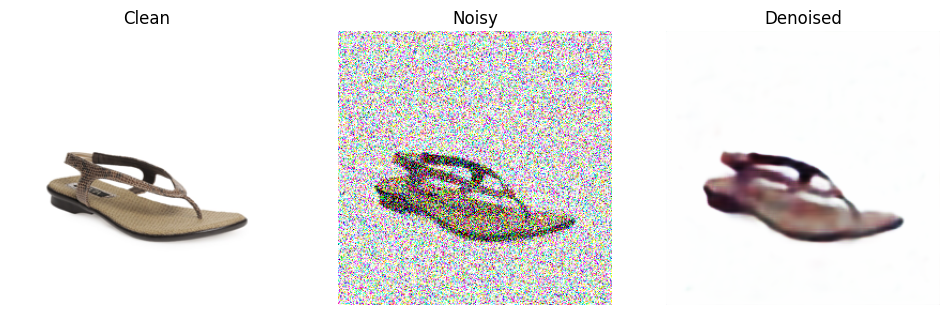

In [12]:
import matplotlib.pyplot as plt

X_noisy, X_clean = next(train_gen)
denoised = autoencoder.predict(X_noisy)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(X_clean[0])
plt.title("Clean")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(X_noisy[0])
plt.title("Noisy")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(denoised[0])
plt.title("Denoised")
plt.axis('off')
plt.show()

In [13]:
def test_generator(X_array, batch_size=BATCH_SIZE, noise_factor=NOISE_FACTOR):
    for start in range(0, len(X_array), batch_size):
        batch_idx = np.arange(start, min(start+batch_size, len(X_array)))
        X_batch = X_array[batch_idx].astype(np.float32)

        X_noisy = X_batch + noise_factor * np.random.normal(0.0, 1.0, X_batch.shape)
        #X_noisy = np.clip(X_noisy, 0.0, 1.0)

        yield X_noisy, X_batch

# Predict and store denoised images
denoised_images = []

for X_noisy_batch, X_clean_batch in test_generator(X[test_idx], batch_size=BATCH_SIZE, noise_factor=NOISE_FACTOR):
    denoised_batch = autoencoder.predict(X_noisy_batch)
    denoised_images.append(denoised_batch)

denoised_images = np.concatenate(denoised_images, axis=0)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━

In [18]:
from tensorflow.keras.models import load_model

autoencoder2 = load_model("/content/drive/MyDrive/processed/Models/dse_complex_mse.keras")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_denoising_results(X, denoised_images, test_idx, n=5, noise_factor=0.5, random_seed=None):
    """
    Plot noisy, denoised, and original images in a 3-row grid.

    Args:
        X: np.array of original images.
        denoised_images: np.array of autoencoder predictions.
        test_idx: list/array of indices to sample from X.
        n: number of images to plot.
        noise_factor: scale of Gaussian noise to add.
        random_seed: optional, for reproducibility.
    """
    if random_seed is not None:
        np.random.seed(random_seed)

    indices_plot = np.random.choice(len(test_idx), n, replace=False)

    plt.figure(figsize=(15, 5))

    for i, idx in enumerate(indices_plot):
        # Noisy
        ax = plt.subplot(3, n, i + 1)
        noisy_img = np.clip(
            X[test_idx[idx]] + noise_factor * np.random.normal(0.0, 1.0, X[test_idx[idx]].shape),
            0.0, 1.0
        )
        plt.imshow(noisy_img)
        plt.title("Noisy")
        plt.axis('off')

        # Denoised
        ax = plt.subplot(3, n, i + 1 + n)
        plt.imshow(denoised_images[idx])
        plt.title("Denoised")
        plt.axis('off')

        # Original
        ax = plt.subplot(3, n, i + 1 + 2 * n)
        plt.imshow(X[test_idx[idx]])
        plt.title("Original")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

plot_denoising_results(X, denoised_images, test_idx, n=5, noise_factor=NOISE_FACTOR, random_seed=42)

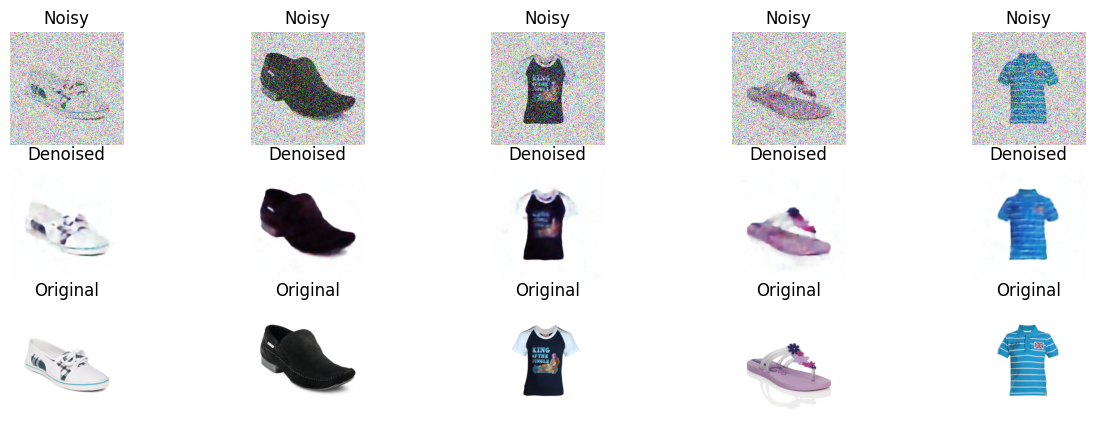

In [14]:
n = 5
indices_plot = np.random.choice(len(test_idx), n, replace=False)

plt.figure(figsize=(15,5))
for i, idx in enumerate(indices_plot):
    # Noisy
    ax = plt.subplot(3, n, i+1)
    noisy_img = np.clip(X[test_idx[idx]] + NOISE_FACTOR * np.random.normal(0.0, 1.0, X[test_idx[idx]].shape), 0.0, 1.0)
    plt.imshow(noisy_img)
    plt.title("Noisy")
    plt.axis('off')

    # Denoised
    ax = plt.subplot(3, n, i+1+n)
    plt.imshow(denoised_images[idx])
    plt.title("Denoised")
    plt.axis('off')

    # Original
    ax = plt.subplot(3, n, i+1+2*n)
    plt.imshow(X[test_idx[idx]])
    plt.title("Original")
    plt.axis('off')
plt.show()

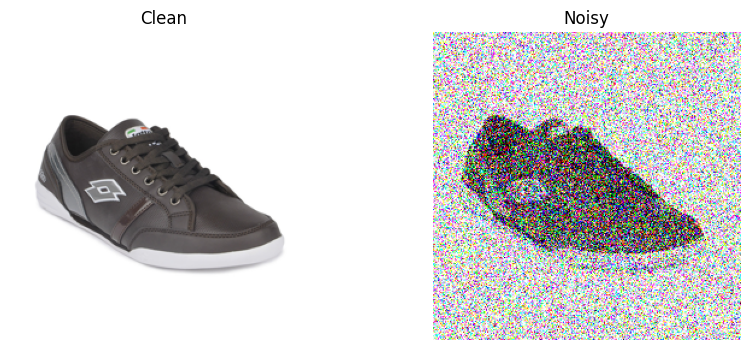

In [16]:
import matplotlib.pyplot as plt

X_noisy, X_clean = next(train_gen)
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.title("Clean")
plt.imshow(X_clean[0])
plt.axis('off')
plt.subplot(1,2,2)
plt.title("Noisy")
plt.imshow(np.clip(X_noisy[0],0,1))
plt.axis('off')
plt.show()

In [13]:
test_input = np.expand_dims(X[test_idx[0]], axis=0)
print("Min/Max input:", test_input.min(), test_input.max())
pred = autoencoder.predict(test_input)
print("Min/Max output:", pred.min(), pred.max())

Min/Max input: 0.1254902 1.0
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Min/Max output: 0.9999988 1.0
